# Математическая статистика для анализа больших данных
## Задание 4
### Робастные оценки.

Выполненную работу нужно отправить телеграм-боту  `@stats_bd_bot`
* Дедлайн см. в телеграм-боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* По практическим задачам прислать нужно ноутбук в формате `ipynb`.
* Решения, размещенные на каких-либо интернет-ресурсах не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Не забывайте делать пояснения и выводы.
* Решение теоретических задач можете записывать в markdown с помощью TeX, присылать в виде фотографий или вшивать в ноутбук через Insert Image (убеждайтесь, что картинка сохраняется при перемещении ноутбука в другое место)

In [ ]:
# Bot check

# HW_ID: sbd_hw4
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Задача 1. (5 баллов)

Докажите, что асимптотическая толерантность медианы средних Уолша $\tau_W \approx 0.29$.



$Y_{ij} = \frac{X_i + X_j}{2}, \; 1 \leq i \leq j \leq n$
$W = \text{med} \{ Y_{ij} \}$

Пусть доля выбросов в выборке равна $\varepsilon$, то есть $k = \varepsilon n$. Общее число средних Уолша:
$N = \frac{n(n+1)}{2}$

Количество некоррумпированных наблюдений:
$n - k = (1 - \varepsilon)n$

Количество некоррумпированных средних Уолша:
$N_{\text{чист}} = \frac{(n-k)(n-k+1)}{2} \approx \frac{[(1 - \varepsilon)n]^2}{2}$

Доля чистых средних Уолша:
$p = \frac{N_{\text{чист}}}{N} \approx \frac{[(1 - \varepsilon)n]^2 / 2}{n^2 / 2} = (1 - \varepsilon)^2$

Условие для устойчивости медианы:
$$(1 - \varepsilon)^2 > 0.5$$

$$1 - \varepsilon > \frac{1}{\sqrt{2}}$$
$$\varepsilon < 1 - \frac{1}{\sqrt{2}}$$

$\tau_W = 1 - \frac{1}{\sqrt{2}} \approx 0.293$

## Задача 2. (10 баллов)
Предлагается изучить некоторые свойства распределения Коши с параметром сдвига $\theta$, обладающего плотностью распределения $p_{\theta}(x) = \frac{1}{\pi \left(1 + \left(x- \theta\right)^2\right)}$.

*Замечание:* Такое распределение встречается, к примеру, в следующей задаче. На высоте 1 метр от точки $\theta$ находится источник $\gamma$-излучения,
причем направления траекторий $\gamma$-квантов случайны, т.е. равномерно распределены по полуокружности. Тогда $X_i, i=1,...,n$ — зарегистрированные координаты точек пересечения $\gamma$-квантов с поверхностью детекторной плоскости — образуют выборку из распределения Коши со сдвигом $\theta$.

**1.** На отрезке $[-7, 7]$ постройте плотность стандартного нормального распределения и стандартного распределения Коши. Не забудьте добавить легенду.

**Решение:**

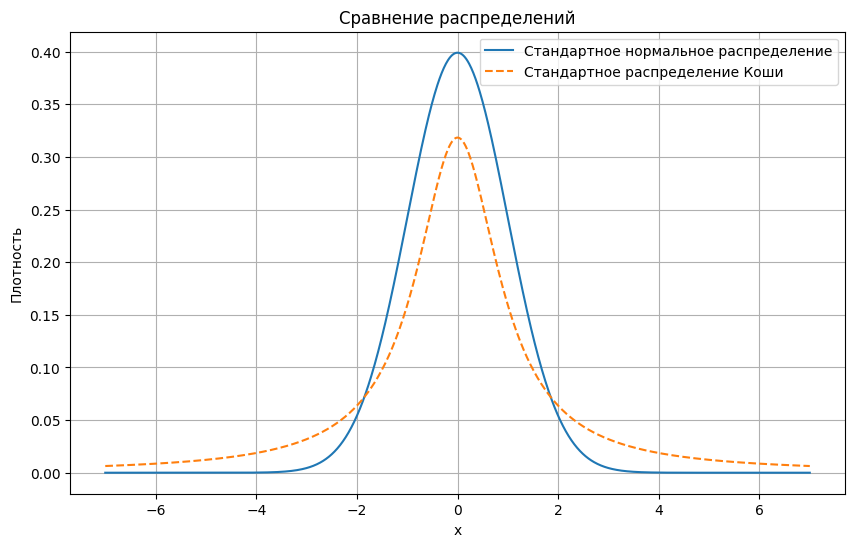

In [22]:
x = np.linspace(-7, 7, 1000)

f_normal = (1 / np.sqrt(2 * np.pi)) * np.exp(-x**2 / 2)
f_cauchy = 1 / (np.pi * (1 + x**2))

plt.figure(figsize=(10, 6))
plt.plot(x, f_normal, label='Стандартное нормальное распределение')
plt.plot(x, f_cauchy, label='Стандартное распределение Коши', linestyle='--')

plt.title('Сравнение распределений')
plt.xlabel('x')
plt.ylabel('Плотность')

plt.legend()
plt.grid(True)

plt.show()

**Вывод:** Стандартное нормальное распределение схоже со стандартным распределением Коши, но при этом демонстрирует более высокую плотность вероятности на интервале $≈[−2,2]$. Вне этого диапазона распределение Коши превосходит нормальное по плотности, что связано с тем, что дисперсия распределения Коши, в отличие от нормального, является бесконечной.

**2.** Чему равна асимптотическая дисперсия $\sigma_{\alpha}^2$ усеченного среднего $\overline{X}_{\alpha}$, где $0 < \alpha < 1/2$, для распределения Коши? Помочь в ее вычислении может теорема, упомянутая на лекциях. Посчитайте асимптотическую дисперсию аналитически.



   $$p(x) = \frac{1}{\pi (1 + x^2)}$$


   $$F(x) = \frac{1}{\pi} \arctan(x) + \frac{1}{2}$$


   $$x_L = F^{-1}(\alpha) = \tan\left( \pi \left( \alpha - \frac{1}{2} \right) \right) = -\cot(\pi \alpha)$$
   $$x_U = F^{-1}(1 - \alpha) = \tan\left( \pi \left( 1 - \alpha - \frac{1}{2} \right) \right) = \cot(\pi \alpha)$$


   $$\sigma_\alpha^2 = \frac{1}{(1 - 2\alpha)^2} \left( \int_{x_L}^{x_U} x^2 p(x) \, dx + 2\alpha x_U^2 \right)$$

   $$\int_{x_L}^{x_U} x^2 p(x) \, dx = 2 \int_0^{x_U} x^2 p(x) \, dx$$

   $$I = \int_0^{x_U} x^2 p(x) \, dx = \int_0^{x_U} \frac{x^2}{\pi (1 + x^2)} \, dx$$
   $$I = \frac{1}{\pi} \int_0^{x_U} \left( 1 - \frac{1}{1 + x^2} \right) dx = \frac{1}{\pi} \left( x_U - \arctan(x_U) \right)$$

   $$\sigma_\alpha^2 = \frac{2}{(1 - 2\alpha)^2} \left( \frac{1}{\pi} (x_U - \arctan(x_U)) + \alpha x_U^2 \right)$$

   Подставим $x_U = \cot(\pi \alpha)$:
   $$x_U = \cot(\pi \alpha), \quad \arctan(x_U) = \arctan(\cot(\pi \alpha)) = \frac{\pi}{2} - \pi \alpha$$

   $$x_U - \arctan(x_U) = \cot(\pi \alpha) + \pi \alpha - \frac{\pi}{2}$$

   $$\sigma_\alpha^2 = \frac{2}{(1 - 2\alpha)^2} \left( \frac{1}{\pi} \left( \cot(\pi \alpha) + \pi \alpha - \frac{\pi}{2} \right) + \alpha \cot^2(\pi \alpha) \right)$$


Постройте график зависимости асимптотической дисперсии $\sigma_{\alpha}^2$ усеченного среднего $\overline{X}_{\alpha}$, где $0 < \alpha < 1/2$, от $\alpha$.

Настройте видимую область графика по оси *y* так, чтобы четко была отображена информативная часть графика. Отметьте на графике минимум функции.

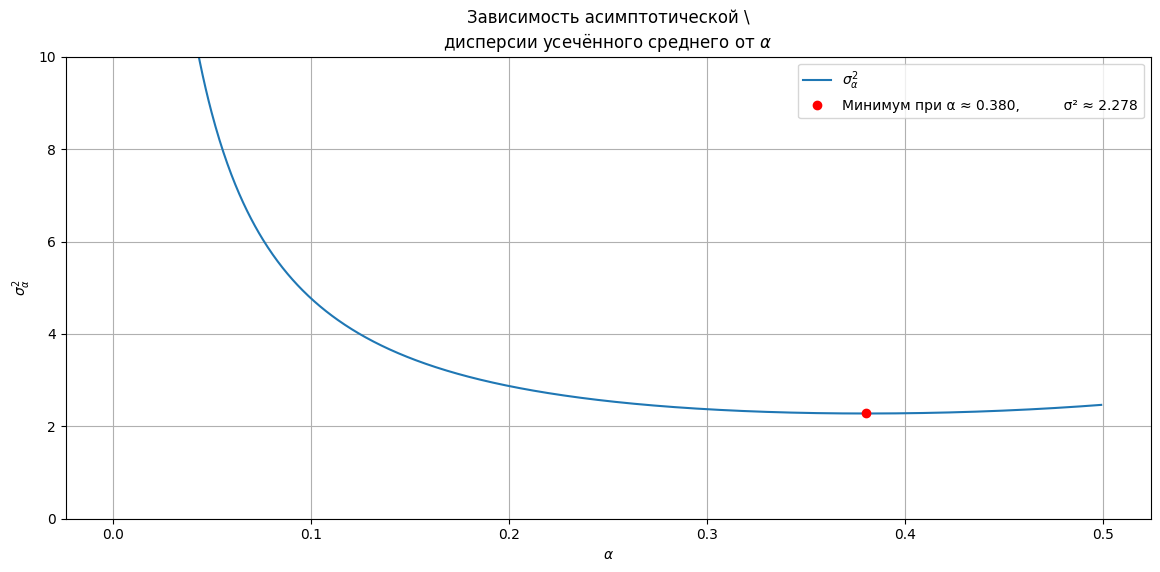

In [23]:
def sigma_alpha_squared(alpha):
    pi = np.pi
    one_minus_2alpha = 1 - 2 * alpha
    u = 1 / np.tan(pi * alpha)
    term1 = (u - np.arctan(u)) / pi
    term2 = alpha * u**2
    sigma_squared = (2 / one_minus_2alpha**2) * (term1 + term2)
    return sigma_squared


alpha_values = np.linspace(0.001, 0.499, 1000)

sigma2_values = sigma_alpha_squared(alpha_values)

min_sigma2 = np.min(sigma2_values)
min_index = np.argmin(sigma2_values)
min_alpha = alpha_values[min_index]

plt.figure(figsize=(14, 6))
plt.plot(alpha_values, sigma2_values, label=r'$\sigma_{\alpha}^2$')

plt.ylim(0, 10)

plt.plot(min_alpha, min_sigma2, 'ro', \
         label=f'Минимум при α ≈ {min_alpha:.3f}, \
         σ² ≈ {min_sigma2:.3f}')

plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\sigma_{\alpha}^2$')
plt.title(r'Зависимость асимптотической \
дисперсии усечённого среднего от $\alpha$')
plt.legend()
plt.grid(True)
plt.show()

При каком значении $\alpha$ асимптотическая дисперсия $\sigma^2_{\alpha}$ минимальна и чему она равна? Ответ можно найти численно.

**Ответ:** $0.38$

**3.** Сгенерируйте выборку $X = \left(X_1, \dots, X_{1000} \right)$ из стандартного распределения Коши. Для всех $n \leqslant 1000$ по первым $n$ элементам выборки $X_1, \dots, X_n$ вычислите значения следующих оценок:
- $\overline{X}$  —  выборочное среднее;
- $\overline{X}_{\alpha}$ —  усеченное среднее, где $\alpha$ &mdash; значение, на котором достигается минимум $\sigma^2_{\alpha}$;
- $\widehat{\mu}$ —  выборочная медиана;
- $W$ — медиана по всем значениям $Y_{ij} = \frac{X_i + X_j}{2}, 1 \leq i \leq j \leq n$ — медиана средних Уолша;

а также, по каждой из этих оценок, одношаговую оценку.
В случае выборочной медианы и медианы средних Уолша можно использовать цикл по подвыборкам.

**Напоминание:** если $\widehat{\theta}_0$ — асимптотически нормальная оценка, то одношаговая оценка $\widehat{\theta}_1$ вычисляется как $\widehat{\theta}_1 = \widehat{\theta}_0 - \left(\ell''_X(\widehat{\theta}_0) \right)^{-1} \ell'_X(\widehat{\theta}_0)$, где $\ell_X(\theta)$ — логарифмическая функция правдоподобия. Заметим, что обычное выборочное среднее не является асимптотически нормальной оценкой, и оценка, вычисленная по формуле выше, формально не является одношаговой, однако для сравнения ее все равно требуется посчитать.

На одном графике изобразите зависимость значений **всех оценок** от $n$ для одной реализации выборки.

Сравните асимптотические дисперсии оценок. Сделайте вывод.

**Решение:**

In [24]:
def walsh_median_fast(X):
    n = X.size
    X_col = X.reshape(-1, 1)
    pairwise_sums = X_col + X
    i_s, j_s = np.triu_indices_from(pairwise_sums)
    unique_sums = pairwise_sums[i_s, j_s]
    walsh_averages = unique_sums / 2.0
    return np.median(walsh_averages)

def log_likelihood_derivative(X, theta):
    return -2 * np.sum((X - theta) / (1 + (X - theta) ** 2))

def log_likelihood_second_derivative(X, theta):
    return -2 * np.sum((1 - (X - theta) ** 2) / \
     (1 + (X - theta) ** 2) ** 2)

In [25]:
np.random.seed(0)
n_max = 1000
X = np.random.standard_cauchy(n_max)

In [26]:
mean_estimates = np.zeros(n_max)
trimmed_mean_estimates = np.zeros(n_max)
median_estimates = np.zeros(n_max)
walsh_median_estimates = np.zeros(n_max)

mean_one_step_estimates = np.zeros(n_max)
trimmed_mean_one_step_estimates = np.zeros(n_max)
median_one_step_estimates = np.zeros(n_max)
walsh_median_one_step_estimates = np.zeros(n_max)


In [28]:
alpha = 0.38

for n in range(1, n_max + 1):
    Xn = X[:n]

    # Выборочное среднее
    mean_estimates[n - 1] = np.mean(Xn)

    # Усечённое среднее
    k = int(np.floor(n * alpha))
    if n - 2 * k > 0:
        sorted_Xn = np.sort(Xn)
        trimmed_Xn = sorted_Xn[k:n - k]
        trimmed_mean_estimates[n - 1] = np.mean(trimmed_Xn)
    else:
        trimmed_mean_estimates[n - 1] = np.nan

    # Выборочная медиана
    median_estimates[n - 1] = np.median(Xn)

    # Медиана средних Уолша
    Wn = walsh_median_fast(Xn)
    walsh_median_estimates[n - 1] = Wn

    # Одношаговые оценки
    # Для выборочного среднего
    theta0 = mean_estimates[n - 1]
    ll_prime = log_likelihood_derivative(Xn, theta0)
    ll_double_prime = log_likelihood_second_derivative(Xn, theta0)
    if ll_double_prime != 0:
        mean_one_step_estimates[n - 1] = \
        theta0 - ll_prime / ll_double_prime
    else:
        mean_one_step_estimates[n - 1] = np.nan

    # Для усечённого среднего
    theta0 = trimmed_mean_estimates[n - 1]
    if np.isnan(theta0):
        trimmed_mean_one_step_estimates[n - 1] = np.nan
    else:
        ll_prime = log_likelihood_derivative(Xn, theta0)
        ll_double_prime = log_likelihood_second_derivative(Xn, theta0)
        if ll_double_prime != 0:
            trimmed_mean_one_step_estimates[n - 1] = \
            theta0 - ll_prime / ll_double_prime
        else:
            trimmed_mean_one_step_estimates[n - 1] = np.nan

    # Для выборочной медианы
    theta0 = median_estimates[n - 1]
    ll_prime = log_likelihood_derivative(Xn, theta0)
    ll_double_prime = log_likelihood_second_derivative(Xn, theta0)
    if ll_double_prime != 0:
        median_one_step_estimates[n - 1] = \
        theta0 - ll_prime / ll_double_prime
    else:
        median_one_step_estimates[n - 1] = np.nan

    # Для медианы Уолша
    theta0 = walsh_median_estimates[n - 1]
    ll_prime = log_likelihood_derivative(Xn, theta0)
    ll_double_prime = log_likelihood_second_derivative(Xn, theta0)
    if ll_double_prime != 0:
        walsh_median_one_step_estimates[n - 1] = \
        theta0 - ll_prime / ll_double_prime
    else:
        walsh_median_one_step_estimates[n - 1] = np.nan


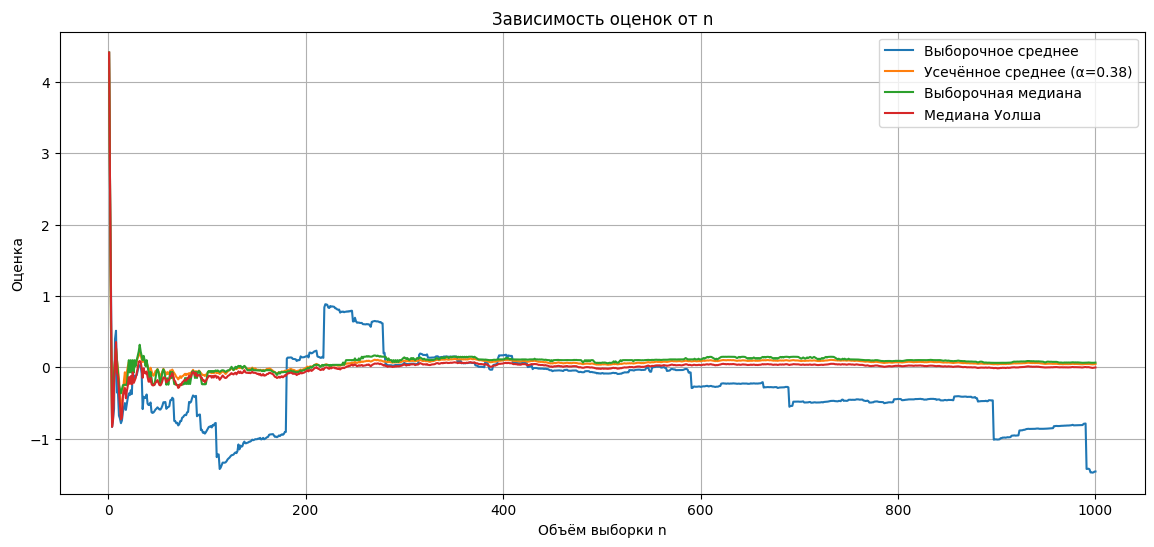

In [38]:
plt.figure(figsize=(14, 6))
plt.plot(range(1, n_max + 1), \
         mean_estimates, label='Выборочное среднее')
plt.plot(range(1, n_max + 1), \
         trimmed_mean_estimates, label=f'Усечённое среднее (α={alpha})')
plt.plot(range(1, n_max + 1), \
         median_estimates, label='Выборочная медиана')
plt.plot(range(1, n_max + 1), \
         walsh_median_estimates, label='Медиана Уолша')
plt.xlabel('Объём выборки n')
plt.ylabel('Оценка')
plt.title('Зависимость оценок от n')
plt.legend()
plt.grid(True)
plt.show()


Взглянем на хвост подробнее:

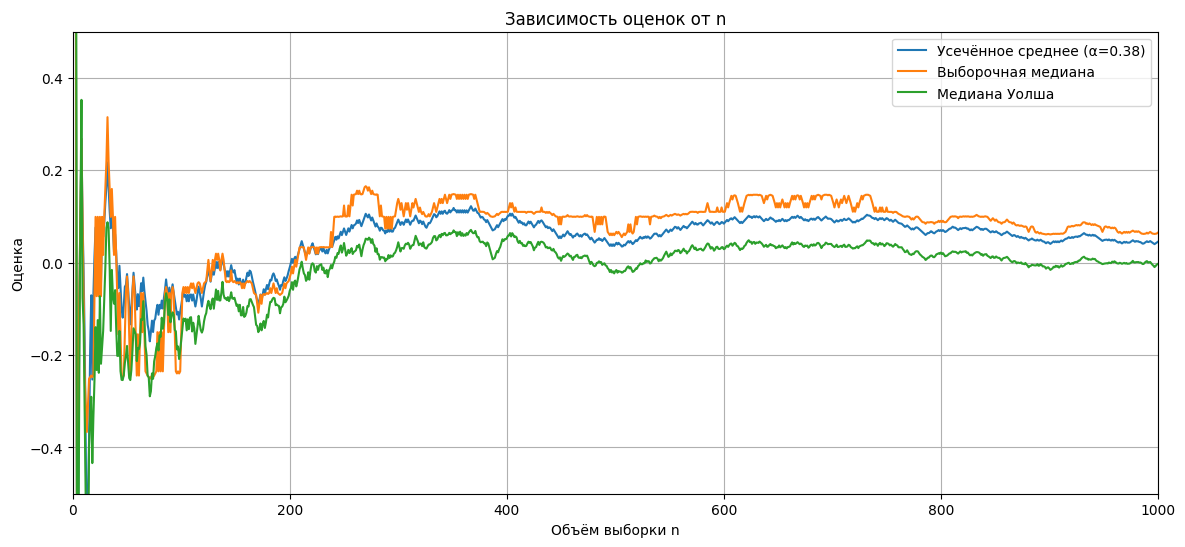

In [39]:
plt.figure(figsize=(14, 6))
plt.plot(range(1, n_max + 1), \
         trimmed_mean_estimates, label=f'Усечённое среднее (α={alpha})')
plt.plot(range(1, n_max + 1), \
         median_estimates, label='Выборочная медиана')
plt.plot(range(1, n_max + 1), \
         walsh_median_estimates, label='Медиана Уолша')
plt.xlabel('Объём выборки n')
plt.ylabel('Оценка')
plt.title('Зависимость оценок от n')
plt.legend()
plt.xlim(0, 1000)
plt.ylim(-0.5, 0.5)
plt.grid(True)
plt.show()


Выборочная медиана < усечённоё среднее < медиана Уошла

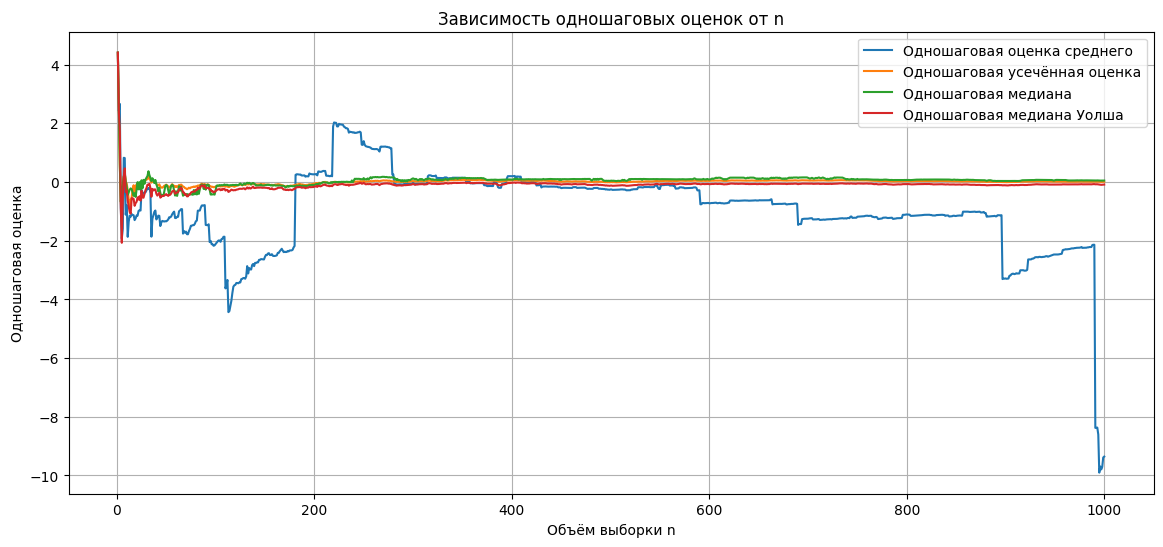

In [40]:
plt.figure(figsize=(14, 6))
plt.plot(range(1, n_max + 1), mean_one_step_estimates, label='Одношаговая оценка среднего')
plt.plot(range(1, n_max + 1), trimmed_mean_one_step_estimates, label='Одношаговая усечённая оценка')
plt.plot(range(1, n_max + 1), median_one_step_estimates, label='Одношаговая медиана')
plt.plot(range(1, n_max + 1), walsh_median_one_step_estimates, label='Одношаговая медиана Уолша')
plt.xlabel('Объём выборки n')
plt.ylabel('Одношаговая оценка')
plt.title('Зависимость одношаговых оценок от n')
plt.legend()
plt.grid(True)
plt.show()


Рассмотрим начало опять же без среднего

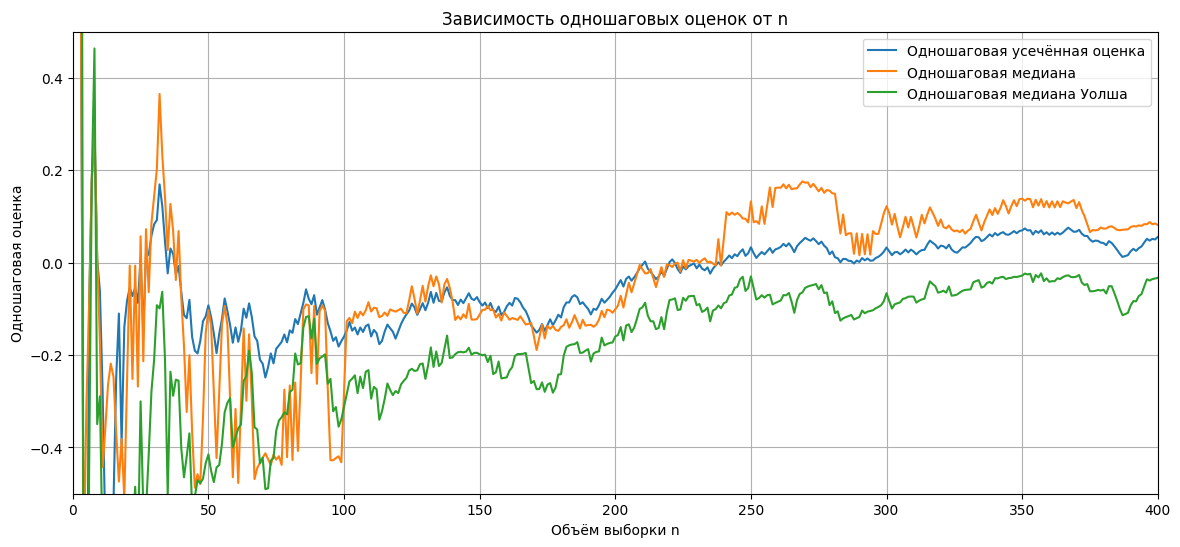

In [46]:
plt.figure(figsize=(14, 6))
plt.plot(range(1, n_max + 1), trimmed_mean_one_step_estimates, label='Одношаговая усечённая оценка')
plt.plot(range(1, n_max + 1), median_one_step_estimates, label='Одношаговая медиана')
plt.plot(range(1, n_max + 1), walsh_median_one_step_estimates, label='Одношаговая медиана Уолша')
plt.xlabel('Объём выборки n')
plt.ylabel('Одношаговая оценка')
plt.title('Зависимость одношаговых оценок от n')
plt.legend()
plt.xlim(0, 400)
plt.ylim(-0.5, 0.5)
plt.grid(True)
plt.grid(True)
plt.show()


Наблюдаем более быструю сходимость

**Вывод:** При оценивании параметра сдвига распределения Коши наиболее предпочтительными являются оценки, устойчивые к выбросам. Выборочное среднее не подходит из-за бесконечной дисперсии и высокой чувствительности к экстремальным значениям. Усечённое среднее при оптимальном значении $\alpha$ обеспечивает наименьшую асимптотическую дисперсию и демонстрирует хорошую сходимость. Выборочная медиана и медиана Уолша также являются надёжными оценками, причём медиана Уолша обладает лучшей эффективностью. Одношаговые оценки улучшают начальные оценки, способствуя более быстрой сходимости и уменьшению дисперсии. Таким образом, для распределения Коши рекомендуется использовать устойчивые оценки, такие как усечённое среднее с оптимальным параметром усечения или медиану Уолша, для получения точных и надёжных результатов.